Satwik Saxena

TCA2357046

In [1]:
import hashlib
import time
import matplotlib.pyplot as plt

In [2]:
class Block:
    def __init__(self, index, previous_hash, timestamp, data, difficulty):
        self.index = index
        self.previous_hash = previous_hash
        self.timestamp = timestamp
        self.data = data
        self.difficulty = difficulty
        self.nonce = 0
        self.hash = self.calculate_hash()

    def calculate_hash(self):
        # Combine the block attributes to create a hash
        block_string = f"{self.index}{self.previous_hash}{self.timestamp}{self.data}{self.nonce}"
        return hashlib.sha256(block_string.encode()).hexdigest()

    def mine_block(self):
        # Adjust the nonce until the hash meets the required difficulty
        target = '0' * self.difficulty
        while self.hash[:self.difficulty] != target:
            self.nonce += 1
            self.hash = self.calculate_hash()

        print(f"Block mined: {self.hash}")

In [3]:
class Blockchain:
    def __init__(self):
        self.chain = [self.create_genesis_block()]

    def create_genesis_block(self):
        # The genesis block is the first block in the chain
        return Block(0, "0", time.time(), "Genesis Block", difficulty=2)  # Default difficulty for the genesis block

    def get_latest_block(self):
        return self.chain[-1]

    def add_block(self, new_block):
        new_block.previous_hash = self.get_latest_block().hash
        new_block.mine_block()  # Mine the block to meet the proof of work requirement
        self.chain.append(new_block)

In [6]:
def main():
    difficulty_levels = [1, 2, 3, 4, 5]  # Different levels of difficulty
    mining_times = []

    for difficulty in difficulty_levels:
        blockchain = Blockchain()
        print(f"\nMining with difficulty level: {difficulty}")

        start_time = time.time()

        print("Mining block 1...")
        block1 = Block(1, "", time.time(), "Block 1 Data", difficulty)
        blockchain.add_block(block1)

        print("Mining block 2...")
        block2 = Block(2, "", time.time(), "Block 2 Data", difficulty)
        blockchain.add_block(block2)

        end_time = time.time()
        mining_times.append(end_time - start_time)

    # Plot the mining times
    plt.figure(figsize=(10, 6))
    plt.plot(difficulty_levels, mining_times, marker='o')
    plt.title('Mining Time vs. Difficulty Level')
    plt.xlabel('Difficulty Level')
    plt.ylabel('Time (seconds)')
    plt.grid(True)
    plt.show()

Satwik Saxena
TCA2357046

Mining with difficulty level: 1
Mining block 1...
Block mined: 0b1378aa90c3dbde2a7033466ef24a40039097c22a06be28090388017654a0cc
Mining block 2...
Block mined: 0b97fa18f08d87c892f52db72430bc54ace1b1fb1394fc5ea9208800bf078455

Mining with difficulty level: 2
Mining block 1...
Block mined: 00e0b15e236c8670eca0d272055e7bcce3798dbcaecb888e11a127bca8876f9f
Mining block 2...
Block mined: 00c43fa0074f102583cd11c40c323140eb0aacc7758f3442a02711d36d1e6e8d

Mining with difficulty level: 3
Mining block 1...
Block mined: 000bd1eaf63d4826b1e34c815e70e624dd9c1b29276298d66a19999a78e026d1
Mining block 2...
Block mined: 0000437e78ba5c8f829b1ecde68594e127214dbe68b569d3025080b04548cc46

Mining with difficulty level: 4
Mining block 1...
Block mined: 000039300b518c23eed6f752a1f1959799ee0e2748e3fce692452538b06aa480
Mining block 2...
Block mined: 00001fdf7b6f236158207370cd90fbe00bbf91aadf7135fd6634e46b23be9459

Mining with difficulty level: 5
Mining block 1...
Block mined: 0000096523a

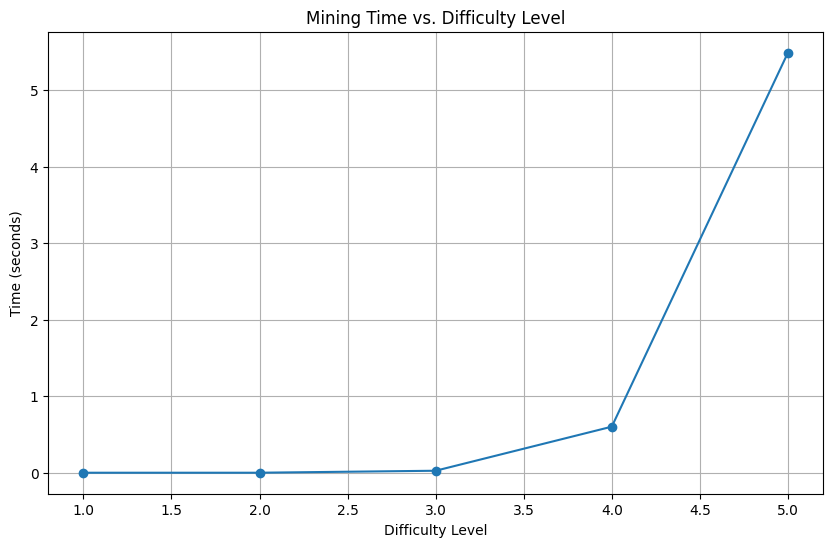

In [8]:
print("Satwik Saxena")
print("TCA2357046")
if __name__ == "__main__":
    main()